# Week 9 demo: matching AI patents

**Research question:** Do AI patents with at least one woman inventor receive more five-year forward citations than otherwise similar all-men AI patents?

**Treatment:** `with_women`  
**Outcome:** `forward_citation_count_five_year`


## 0. Packages and display settings


In [1]:
from pathlib import Path

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import seaborn as sns
from sklearn.compose import ColumnTransformer
from sklearn.linear_model import LogisticRegression
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import OneHotEncoder, StandardScaler

OUTPUT_DIR = Path("build/week9-ai-patent-matching")
OUTPUT_DIR.mkdir(parents=True, exist_ok=True)

COLORS = {
    "navy": "#17324D",
    "teal": "#2A7F86",
    "amber": "#D99731",
    "coral": "#C75B4B",
    "gray": "#66737F",
}
sns.set_theme(style="whitegrid", context="talk")


## 1. Load and prepare the patent data

Read and inspect the data


In [ ]:
DATA_PATH = "data/ai_patents_with_gender_attribtue_for_matching_20261004.csv"
patents = pd.read_csv(DATA_PATH, dtype={"patent_id": str,
                                        'team_size': int})

In [8]:
patents.head()

,patent_id,with_women,filing_year,team_size,num_claims,cpc_subclass_count,backward_citation_count,originality,forward_citation_count_five_year
0,6690204,1,2002,3,24,1,4,0.000000,10
1,11393224,0,2021,3,13,3,2,0.720000,1
2,10285325,0,2010,3,16,2,17,0.714533,0
3,9135500,0,2012,1,19,1,2,0.720000,3
4,11548150,0,2020,2,14,2,2,0.444444,0


In [9]:
patents.shape

(299936, 9)

In [10]:
treatment = "with_women"
outcome = "forward_citation_count_five_year"

numeric_covariates = [
    "team_size",
    "num_claims",
    "cpc_subclass_count",
    "backward_citation_count",
    "originality",
]
categorical_covariates = ["filing_year"]
matching_covariates = numeric_covariates + categorical_covariates

analysis_vars = ["patent_id", treatment, outcome] + matching_covariates
patents = patents[analysis_vars].dropna().copy()
patents[treatment] = patents[treatment].astype(int)
patents["group"] = patents[treatment].map({0: "All-men", 1: "With women"})

print(f"Analytical sample: {len(patents):,} patents")
patents.head()


Analytical sample: 250,098 patents


,patent_id,with_women,forward_citation_count_five_year,team_size,num_claims,cpc_subclass_count,backward_citation_count,originality,filing_year,group
0,6690204,1,10,3,24,1,4,0.000000,2002,With women
1,11393224,0,1,3,13,3,2,0.720000,2021,All-men
2,10285325,0,0,3,16,2,17,0.714533,2010,All-men
3,9135500,0,3,1,19,1,2,0.720000,2012,All-men
4,11548150,0,0,2,14,2,2,0.444444,2020,All-men


## 2. Begin with the unmatched comparison


In [11]:
summary_before = (
    patents.groupby("group", observed=True)
    .agg(
        n=("patent_id", "size"),
        mean_team_size=("team_size", "mean"),
        mean_claims=("num_claims", "mean"),
        mean_cpc_subclasses=("cpc_subclass_count", "mean"),
        mean_backward_citations=("backward_citation_count", "mean"),
        mean_originality=("originality", "mean"),
        mean_five_year_citations=(outcome, "mean"),
    )
    .round(2)
)
summary_before


,n,mean_team_size,mean_claims,mean_cpc_subclasses,mean_backward_citations,mean_originality,mean_five_year_citations
group,,,,,,,
All-men,185234,2.57,20.99,2.13,26.68,0.63,5.59
With women,64864,4.17,20.61,2.16,23.74,0.63,5.24


In [12]:
naive_difference = (
    patents.loc[patents[treatment] == 1, outcome].mean()
    - patents.loc[patents[treatment] == 0, outcome].mean()
)

print(f"Naive difference: {naive_difference:.2f} five-year citations")


Naive difference: -0.34 five-year citations


### Pause and discuss

Are patents with and without women directly comparable? Which observed differences might confound the comparison?


## 3. Estimate propensity scores

Estimate each patent's probability of having at least one woman inventor from observed covariates.


In [13]:
preprocessor = ColumnTransformer(
    transformers=[
        ("numeric", StandardScaler(), numeric_covariates),
        ("categorical", OneHotEncoder(handle_unknown="ignore"), categorical_covariates),
    ]
)

propensity_model = Pipeline([
    ("preprocess", preprocessor),
    ("logit", LogisticRegression(max_iter=2_000)),
])

propensity_model.fit(patents[matching_covariates], patents[treatment])
patents["propensity_score"] = propensity_model.predict_proba(
    patents[matching_covariates]
)[:, 1]

patents[["patent_id", treatment, "propensity_score"]].head()


,patent_id,with_women,propensity_score
0,6690204,1,0.244136
1,11393224,0,0.277577
2,10285325,0,0.216684
3,9135500,0,0.112494
4,11548150,0,0.202741


## 4. Inspect overlap

What are we looking for?
- Difference: The treatment and control groups have different propensity-score distributions.
- Overlap: There are regions containing both treated and control observations, so matching is possible. There is actually a lot of overlap. For many patents with women, we can find all-men patents with similar propensity scores. Those are the comparisons we want to make.
- Limited overlap: In some regions, especially at high propensity scores, good matches may be harder to find.

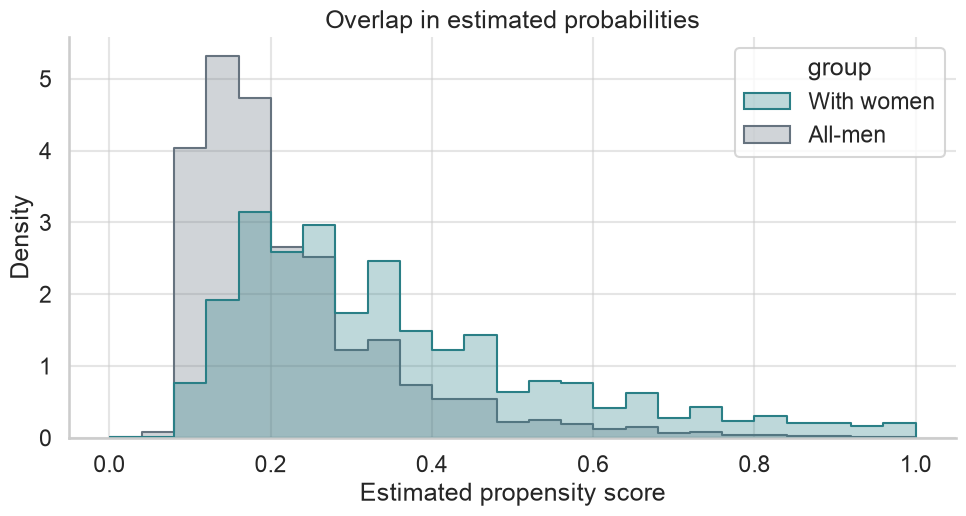

In [14]:
fig, ax = plt.subplots(figsize=(10, 5.5))
sns.histplot(
    data=patents,
    x="propensity_score",
    hue="group",
    stat="density",
    common_norm=False,
    element="step",
    fill=True,
    alpha=0.30,
    bins=25,
    palette={"With women": COLORS["teal"], "All-men": COLORS["gray"]},
    ax=ax,
)
ax.set(
    xlabel="Estimated propensity score",
    ylabel="Density",
    title="Overlap in estimated probabilities",
)
sns.despine()
fig.tight_layout()
plt.show()


In [15]:
treated_scores = patents.loc[patents[treatment] == 1, "propensity_score"]
control_scores = patents.loc[patents[treatment] == 0, "propensity_score"]

support_low = max(treated_scores.min(), control_scores.min())
support_high = min(treated_scores.max(), control_scores.max())

on_support = patents["propensity_score"].between(support_low, support_high)
analysis_pool = patents.loc[on_support].copy()

print(f"Common-support interval: {support_low:.3f} to {support_high:.3f}")
print(f"Patents outside common support: {(~on_support).sum():,}")


Common-support interval: 0.001 to 0.997
Patents outside common support: 63


## 5. Find nearest neighbors

For each patent with women, find the all-men patent from the same filing year with the nearest propensity score. This uses 1:1 matching with replacement.


In [18]:
CALIPER = 0.01#0.03
treated_pool = analysis_pool.loc[analysis_pool[treatment] == 1]
control_pool = analysis_pool.loc[analysis_pool[treatment] == 0]

matches = []
for treated_index, treated_patent in treated_pool.iterrows():
    eligible_controls = control_pool.loc[
        control_pool["filing_year"] == treated_patent["filing_year"]
    ].copy()

    if eligible_controls.empty:
        continue

    distances = (
        eligible_controls["propensity_score"]
        - treated_patent["propensity_score"]
    ).abs()
    control_index = distances.idxmin()
    distance = distances.loc[control_index]

    if distance <= CALIPER:
        matches.append({
            "treated_index": treated_index,
            "control_index": control_index,
            "distance": distance,
        })

pairs = pd.DataFrame(matches)
print(f"Patents with women on common support: {len(treated_pool):,}")
print(f"Successfully matched: {len(pairs):,}")
print(f"Match rate: {len(pairs) / len(treated_pool):.1%}")


Patents with women on common support: 64,801
Successfully matched: 64,551
Match rate: 99.6%


In [19]:
matched_treated = patents.loc[pairs["treated_index"]].reset_index(drop=True)
matched_controls = patents.loc[pairs["control_index"]].reset_index(drop=True)

matched_pairs = pd.DataFrame({
    "patent_with_women": matched_treated["patent_id"],
    "matched_all_men_patent": matched_controls["patent_id"],
    "filing_year": matched_treated["filing_year"],
    "treated_score": matched_treated["propensity_score"],
    "control_score": matched_controls["propensity_score"],
    "score_distance": pairs["distance"].to_numpy(),
    "treated_citations": matched_treated[outcome],
    "control_citations": matched_controls[outcome],
})
matched_pairs.head(10).round(3)


,patent_with_women,matched_all_men_patent,filing_year,treated_score,control_score,score_distance,treated_citations,control_citations
0,6690204,8044793,2002,0.244,0.244,0.0,10,2
1,6401050,6594030,1999,0.160,0.160,0.0,3,7
2,11656157,11268890,2020,0.369,0.369,0.0,0,1
3,10628895,10446271,2015,0.247,0.247,0.0,2,2
4,10866926,10725797,2017,0.358,0.358,0.0,3,0
5,9519957,9460235,2014,0.254,0.254,0.0,2,0
6,9934300,10459942,2016,0.582,0.582,0.0,0,2
7,11481313,11810089,2021,0.476,0.475,0.0,2,0
8,10228825,8745351,2013,0.178,0.178,0.0,1,2
9,6584034,6960756,2002,0.241,0.241,0.0,3,2


### Pause and inspect the pairs

Are the propensity scores close? What happens if the caliper is made smaller?


## 6. Check covariate balance

Use standardized mean differences (SMDs) before and after matching.


In [20]:
def standardized_mean_difference(treated_values, control_values):
    treated_values = np.asarray(treated_values, dtype=float)
    control_values = np.asarray(control_values, dtype=float)
    pooled_sd = np.sqrt(
        (treated_values.var(ddof=1) + control_values.var(ddof=1)) / 2
    )
    if pooled_sd == 0:
        return 0.0
    return (treated_values.mean() - control_values.mean()) / pooled_sd

balance_rows = []
for covariate in numeric_covariates:
    before = standardized_mean_difference(
        patents.loc[patents[treatment] == 1, covariate],
        patents.loc[patents[treatment] == 0, covariate],
    )
    after = standardized_mean_difference(
        matched_treated[covariate],
        matched_controls[covariate],
    )
    balance_rows.append({
        "covariate": covariate,
        "before_matching": before,
        "after_matching": after,
    })

balance = pd.DataFrame(balance_rows)
balance.round(3)


,covariate,before_matching,after_matching
0,team_size,0.779,0.002
1,num_claims,-0.035,0.003
2,cpc_subclass_count,0.021,0.029
3,backward_citation_count,-0.035,0.001
4,originality,-0.012,0.024


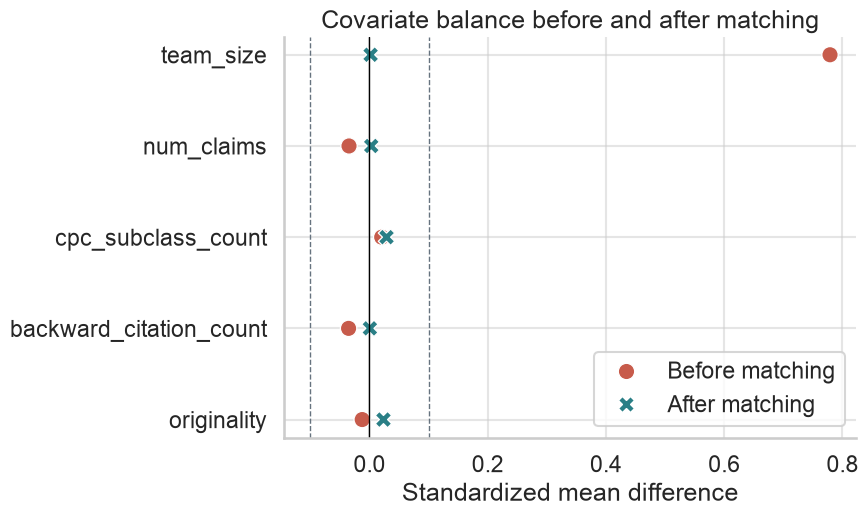

In [21]:
plot_balance = balance.melt(
    id_vars="covariate",
    var_name="sample",
    value_name="smd",
)
plot_balance["sample"] = plot_balance["sample"].map({
    "before_matching": "Before matching",
    "after_matching": "After matching",
})

fig, ax = plt.subplots(figsize=(9, 5.5))
sns.scatterplot(
    data=plot_balance,
    x="smd",
    y="covariate",
    hue="sample",
    style="sample",
    s=140,
    palette={"Before matching": COLORS["coral"], "After matching": COLORS["teal"]},
    ax=ax,
)
ax.axvline(0, color="black", linewidth=1)
ax.axvline(-0.10, color=COLORS["gray"], linestyle="--", linewidth=1)
ax.axvline(0.10, color=COLORS["gray"], linestyle="--", linewidth=1)
ax.set(
    xlabel="Standardized mean difference",
    ylabel="",
    title="Covariate balance before and after matching",
)
ax.legend(title="", loc="best")
sns.despine()
fig.tight_layout()
plt.show()


- Before matching, look at team size. Its standardized mean difference is 0.779, meaning patents with women and all-men patents differ substantially in team size. After matching, the SMD falls to 0.002. So our matched comparison group now looks extremely similar to the treated group in team size.
- The other variables were already fairly well balanced before matching because their absolute SMDs were below 0.1. After matching, they remain very close to zero.
- Matching appears to have achieved excellent balance on all five observed covariates.
- With caliper = 0.01, we got: 99.6% match rate + all post-match |SMD| < 0.03.

## 7. Estimate the ATT

Compare five-year forward citations within the matched pairs.


In [22]:
pair_differences = (
    matched_treated[outcome].to_numpy()
    - matched_controls[outcome].to_numpy()
)

estimated_att = pair_differences.mean()
standard_error = pair_differences.std(ddof=1) / np.sqrt(len(pair_differences))
confidence_interval = (
    estimated_att - 1.96 * standard_error,
    estimated_att + 1.96 * standard_error,
)

results = pd.DataFrame({
    "estimate": [naive_difference, estimated_att],
}, index=[
    "Naive difference",
    "Matched ATT",
])

display(results.round(2))
print(
    f"Approximate 95% CI for matched ATT: "
    f"[{confidence_interval[0]:.2f}, {confidence_interval[1]:.2f}]"
)


,estimate
Naive difference,-0.34
Matched ATT,-0.32


Approximate 95% CI for matched ATT: [-0.48, -0.15]


- Naive difference = −0.34: Before accounting for the observed differences between the groups, patents with women receive, on average, about 0.34 fewer five-year forward citations than all-men patents.
- Matched ATT = −0.32: After matching patents with women to comparable all-men patents, the estimated difference is about −0.32 citations. ATT means Average Treatment Effect on the Treated—here, the estimated difference specifically for patents with women relative to their matched all-men comparison patents.
- The estimate changes only slightly: −0.34 → −0.32. This suggests that adjusting for these observed covariates does not substantially change the estimated difference in citation impact, even though matching dramatically improved covariate balance.
- 95% CI = [−0.48, −0.15]: The interval does not include zero, so under the assumptions behind this approximate CI, the matched difference is statistically distinguishable from zero.
- But be careful with causal language: Matching balances the observed covariates included in the analysis; it does not eliminate unobserved confounding. I would describe this as an estimated matched difference unless the research design supports stronger causal claims.


## 8. Interpretation and limitations

The matched estimate compares AI patents involving women with observationally similar all-men patents. Matching can improve balance on observed characteristics, but it does **not** eliminate unmeasured confounding.

### Final discussion

1. What important confounders might still be missing?
2. Should we match on technological field as well as filing year?
3. What changes if we use patent novelty rather than citations as the outcome?


# Optional: Matching without replacement

In [25]:
# 1:1 nearest-neighbor propensity score matching WITHOUT replacement

caliper = 0.01

treated = patents[
    (patents["with_women"] == 1) &
    (patents["propensity_score"].between(support_low, support_high))
].copy()

controls = patents[
    (patents["with_women"] == 0) &
    (patents["propensity_score"].between(support_low, support_high))
].copy()

# Keep track of controls that are still available
available_controls = controls.copy()

matches = []

for treated_idx, treated_row in treated.iterrows():

    # Find available controls in the same filing year
    candidates = available_controls[
        available_controls["filing_year"] == treated_row["filing_year"]
    ].copy()

    if len(candidates) == 0:
        continue

    # Calculate propensity-score distance
    candidates["ps_distance"] = abs(
        candidates["propensity_score"] -
        treated_row["propensity_score"]
    )

    # Find nearest available control
    best_control_idx = candidates["ps_distance"].idxmin()
    best_distance = candidates.loc[best_control_idx, "ps_distance"]

    # Accept only if within caliper
    if best_distance <= caliper:

        matches.append({
            "treated_idx": treated_idx,
            "control_idx": best_control_idx,
            "ps_distance": best_distance
        })

        # Remove selected control so it cannot be used again
        available_controls = available_controls.drop(best_control_idx)

Then check how many were successfully matched:

In [28]:
matched_pairs = pd.DataFrame(matches)

n_treated = len(treated)
n_matched = len(matched_pairs)

print(f"Patents with women on common support: {n_treated:,}")
print(f"Successfully matched: {n_matched:,}")
print(f"Match rate: {n_matched / n_treated * 100:.1f}%")

Patents with women on common support: 64,801
Successfully matched: 59,937
Match rate: 92.5%


In [29]:
# Create matched treated and control datasets

matched_treated = patents.loc[
    matched_pairs["treated_idx"]
].copy()

matched_control = patents.loc[
    matched_pairs["control_idx"]
].copy()

# Reset indices so each row corresponds to one matched pair
matched_treated = matched_treated.reset_index(drop=True)
matched_control = matched_control.reset_index(drop=True)

# Assign matched-pair ID
matched_treated["group_id"] = range(len(matched_treated))
matched_control["group_id"] = range(len(matched_control))

print("Matched treated patents:", len(matched_treated))
print("Matched control patents:", len(matched_control))

Matched treated patents: 59937
Matched control patents: 59937


In [30]:
matched_df = pd.concat(
    [matched_treated, matched_control],
    ignore_index=True
)

print("Total observations in matched sample:", len(matched_df))

Total observations in matched sample: 119874


In [31]:
covariates = [
    "team_size",
    "num_claims",
    "cpc_subclass_count",
    "backward_citation_count",
    "originality"
]

def standardized_mean_difference(treated, control, variable):
    mean_t = treated[variable].mean()
    mean_c = control[variable].mean()

    var_t = treated[variable].var()
    var_c = control[variable].var()

    pooled_sd = np.sqrt((var_t + var_c) / 2)

    return (mean_t - mean_c) / pooled_sd


balance_results = []

for variable in covariates:

    # Before matching
    smd_before = standardized_mean_difference(
        treated,
        controls,
        variable
    )

    # After matching
    smd_after = standardized_mean_difference(
        matched_treated,
        matched_control,
        variable
    )

    balance_results.append({
        "covariate": variable,
        "SMD_before": smd_before,
        "SMD_after": smd_after
    })

balance_df = pd.DataFrame(balance_results)

balance_df.round(3)

,covariate,SMD_before,SMD_after
0,team_size,0.790,0.001
1,num_claims,-0.035,0.002
2,cpc_subclass_count,0.020,0.017
3,backward_citation_count,-0.037,-0.002
4,originality,-0.012,0.016


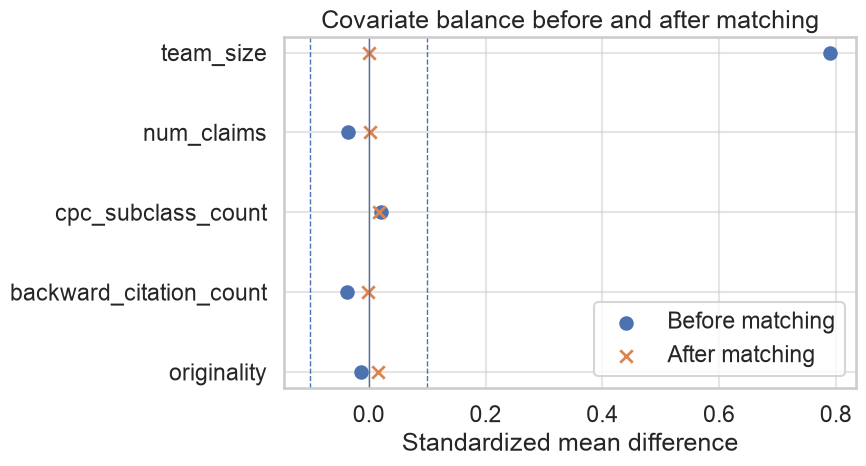

In [32]:
plot_df = balance_df.iloc[::-1]

plt.figure(figsize=(9, 5))

plt.scatter(
    plot_df["SMD_before"],
    plot_df["covariate"],
    label="Before matching",
    s=80
)

plt.scatter(
    plot_df["SMD_after"],
    plot_df["covariate"],
    label="After matching",
    marker="x",
    s=80,
    linewidths=2
)

# Reference line at zero
plt.axvline(0, linewidth=1)

# Common balance thresholds
plt.axvline(0.1, linestyle="--", linewidth=1)
plt.axvline(-0.1, linestyle="--", linewidth=1)

plt.xlabel("Standardized mean difference")
plt.ylabel("")
plt.title("Covariate balance before and after matching")
plt.legend()

plt.tight_layout()
plt.show()

In [36]:
standard_error = (
    pair_differences.std(ddof=1) /
    np.sqrt(len(pair_differences))
)

confidence_interval = (
    estimated_att - 1.96 * standard_error,
    estimated_att + 1.96 * standard_error,
)

print(f"Matched ATT: {estimated_att:.2f}")
print(
    f"Approximate 95% CI: "
    f"[{confidence_interval[0]:.2f}, "
    f"{confidence_interval[1]:.2f}]"
)

Matched ATT: -0.41
Approximate 95% CI: [-0.58, -0.24]


one limitation: because we are using greedy matching without replacement, the matches can depend on the order in which treated patents are processed